In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# ---- Paths / ticker ----
INPUT_CSV   = "SPY.csv"
TICKER      = "SPY"

# ---- Expanding-window setup ----
INIT_YEARS  = 4           # first 4 years to estimate the very first model
STEP_MONTHS = 1           # predict 1 calendar month each iteration

# ---- EXACT candidate aggregation windows (trading days) ----
CANDS = [1, 5, 16, 22, 32, 44, 66, 88]

# Metrics
ASSUME_SERIES_IS_VARIANCE = False  # if your RV is volatility (std), set False so QLIKE uses squares
_EPS = 1e-12

# Optional date bounds (None = full file)
DATA_START = None
DATA_END   = None


In [9]:
def load_rv(input_csv: str) -> pd.Series:
    df = pd.read_csv(input_csv)
    df = df[["Date", "Volatility", "Type"]].copy()
    df.rename(columns={"Volatility": "RV_daily"}, inplace=True)
    df = df[df["Type"] == "QMLE-Trade"].copy()
    df.drop(columns=["Type"], inplace=True)

    df["Date"] = pd.to_datetime(df["Date"])
    df = df.set_index("Date").sort_index()
    if DATA_START is not None:
        df = df[df.index >= pd.Timestamp(DATA_START)]
    if DATA_END is not None:
        df = df[df.index <= pd.Timestamp(DATA_END)]

    df["RV_daily"] = pd.to_numeric(df["RV_daily"], errors="coerce")
    s = df["RV_daily"].dropna().copy()
    s.index.name = "date"
    return s

rv = load_rv(INPUT_CSV)
print(f"{TICKER} RV loaded: {rv.index.min().date()} → {rv.index.max().date()}  (N={len(rv):,})")
rv.head()


SPY RV loaded: 1996-01-02 → 2025-04-29  (N=7,301)


date
1996-01-02    0.140261
1996-01-03    0.082399
1996-01-04    0.211454
1996-01-05    0.022647
1996-01-09    0.228727
Name: RV_daily, dtype: float64

In [10]:
def make_har_design(rv: pd.Series, cands: list[int]) -> pd.DataFrame:
    """
    Build once, reuse many times:
      y     = log1p(RV_t)
      x1    = log1p(RV_{t-1})
      xw_k  = log1p(mean RV_{t-k..t-1}) for each k in cands
      xm_k  = log1p(mean RV_{t-k..t-1}) for each k in cands
    """
    df = pd.DataFrame({"RV": rv})
    df["y"]  = np.log1p(df["RV"])
    df["x1"] = np.log1p(df["RV"].shift(1))

    # Precompute rolling means once
    for k in sorted(set(cands)):
        df[f"xw_{k}"] = np.log1p(df["RV"].rolling(k).mean().shift(1))
        df[f"xm_{k}"] = np.log1p(df["RV"].rolling(k).mean().shift(1))

    # Drop rows that don't have enough history for the largest window
    need_cols = ["y", "x1"] + [f"xw_{k}" for k in cands] + [f"xm_{k}" for k in cands]
    df = df.dropna(subset=need_cols)
    return df

design = make_har_design(rv, CANDS)
print("Design rows (after max-window drop):", len(design))
design.head()


Design rows (after max-window drop): 7213


,RV,y,x1,xw_1,xm_1,xw_5,xm_5,xw_16,xm_16,xw_22,xm_22,xw_32,xm_32,xw_44,xm_44,xw_66,xm_66,xw_88,xm_88
date,,,,,,,,,,,,,,,,,,,
1996-05-08,0.218247,0.197413,0.088245,0.088245,0.088245,0.108857,0.108857,0.087761,0.087761,0.104950,0.104950,0.097683,0.097683,0.107592,0.107592,0.112242,0.112242,0.109119,0.109119
1996-05-09,0.122295,0.115376,0.197413,0.197413,0.197413,0.131333,0.131333,0.097493,0.097493,0.106830,0.106830,0.102296,0.102296,0.110768,0.110768,0.113830,0.113830,0.109913,0.109913
1996-05-10,0.078293,0.075379,0.115376,0.115376,0.115376,0.130689,0.130689,0.098004,0.098004,0.108261,0.108261,0.102354,0.102354,0.111348,0.111348,0.114085,0.114085,0.110319,0.110319
1996-05-13,0.129667,0.121923,0.075379,0.075379,0.075379,0.118840,0.118840,0.096461,0.096461,0.102238,0.102238,0.102265,0.102265,0.104420,0.104420,0.113726,0.113726,0.108963,0.108963
1996-05-14,0.032707,0.032183,0.121923,0.121923,0.121923,0.120580,0.120580,0.100396,0.100396,0.096101,0.096101,0.102984,0.102984,0.102352,0.102352,0.114125,0.114125,0.110053,0.110053


In [11]:
def month_range_indices(idx: pd.DatetimeIndex, start: pd.Timestamp, months: int = 1) -> pd.DatetimeIndex:
    end = start + pd.DateOffset(months=months)
    return idx[(idx >= start) & (idx < end)]

def bic_from_rss(n: int, rss: float, k_params: int) -> float:
    # BIC = n*ln(RSS/n) + k*ln(n); k = effective #parameters (rank of X)
    return n * np.log(rss / max(n, 1)) + k_params * np.log(max(n, 1))

def qlike_loss(y_true, y_pred, assume_variance=True, eps=_EPS):
    yt = np.asarray(y_true, dtype=float)
    yp = np.asarray(y_pred, dtype=float)
    if not assume_variance:
        yt = yt**2
        yp = yp**2
    yt = np.clip(yt, eps, None)
    yp = np.clip(yp, eps, None)
    return float(np.mean(yt/yp - np.log(yt/yp) - 1.0))


In [12]:
def har_expanding_forecast(design: pd.DataFrame,
                           init_years: int = 4,
                           step_months: int = 1,
                           verbose_every: int = 12) -> pd.DataFrame:
    """
    Same interface/output as before, but:
      - Each round selects (w*, m*) from CANDS by TRAIN BIC for y ~ const + x1 + xw_w + xm_m
      - Predicts the next month using the chosen pair
    Returns: date, RV_actual, RV_predicted  (RAW RV, non-negative)
    """
    idx_all = design.index
    base_start = idx_all[0]
    test_start = base_start + pd.DateOffset(years=init_years)

    out_rows, rounds = [], 0

    while True:
        test_idx = month_range_indices(idx_all, test_start, months=step_months)
        if len(test_idx) == 0: break

        train_idx = idx_all[idx_all < test_start]
        if len(train_idx) < 50:
            test_start += pd.DateOffset(months=step_months)
            continue

        # ------- BIC model selection on TRAIN -------
        y_tr  = design.loc[train_idx, "y"].values
        x1_tr = design.loc[train_idx, "x1"].values
        best = {"bic": np.inf, "w": None, "m": None, "params": None}

        for w in CANDS:
            xw = design.loc[train_idx, f"xw_{w}"].values
            for m in CANDS:
                xm = design.loc[train_idx, f"xm_{m}"].values

                X_tr = np.column_stack([np.ones_like(x1_tr), x1_tr, xw, xm])
                # Effective parameter count = rank (handles duplicates like w=1 ~ x1)
                k_eff = int(np.linalg.matrix_rank(X_tr))
                # Fit OLS and compute RSS
                model = sm.OLS(y_tr, X_tr, hasconst=True).fit()
                resid = y_tr - model.predict(X_tr)
                rss   = float(np.sum(resid**2))
                n     = X_tr.shape[0]
                bic   = bic_from_rss(n, rss, k_eff)

                if bic < best["bic"]:
                    best = {"bic": bic, "w": w, "m": m, "params": model.params}

        # ------- Predict TEST with (w*, m*) -------
        w_star, m_star = best["w"], best["m"]
        X_te = sm.add_constant(
            design.loc[test_idx, ["x1", f"xw_{w_star}", f"xm_{m_star}"]],
            has_constant="add"
        ).values
        yhat_log = X_te @ best["params"]
        yhat_raw = np.maximum(np.expm1(yhat_log), 0.0)

        # Actuals (raw)
        y_true = rv.loc[test_idx].values
        y_true = np.maximum(np.where(np.isfinite(y_true), y_true, 0.0), 0.0)

        out_rows.append(pd.DataFrame({
            "date": test_idx,
            "RV_actual": y_true,
            "RV_predicted": yhat_raw
        }))

        rounds += 1
        if verbose_every and (rounds % verbose_every == 0):
            print(f"…{rounds} months done through {test_idx[-1].date()} | BIC-chosen (w,m)=({w_star},{m_star})")

        # advance
        next_start = test_start + pd.DateOffset(months=step_months)
        if next_start > idx_all[-1]: break
        test_start = next_start

    if not out_rows:
        return pd.DataFrame(columns=["date","RV_actual","RV_predicted"])

    out = pd.concat(out_rows, axis=0).sort_values("date").reset_index(drop=True)
    return out

oos_har = har_expanding_forecast(design, init_years=INIT_YEARS, step_months=STEP_MONTHS)
print(f"OOS rows: {len(oos_har):,}")
oos_har.head()


…12 months done through 2001-05-07 | BIC-chosen (w,m)=(5,16)
…24 months done through 2002-05-07 | BIC-chosen (w,m)=(5,16)
…36 months done through 2003-05-07 | BIC-chosen (w,m)=(5,16)
…48 months done through 2004-05-07 | BIC-chosen (w,m)=(5,16)
…60 months done through 2005-05-06 | BIC-chosen (w,m)=(5,16)
…72 months done through 2006-05-05 | BIC-chosen (w,m)=(5,16)
…84 months done through 2007-05-07 | BIC-chosen (w,m)=(5,16)
…96 months done through 2008-05-07 | BIC-chosen (w,m)=(5,16)
…108 months done through 2009-05-07 | BIC-chosen (w,m)=(5,16)
…120 months done through 2010-05-07 | BIC-chosen (w,m)=(5,16)
…132 months done through 2011-05-06 | BIC-chosen (w,m)=(5,16)
…144 months done through 2012-05-07 | BIC-chosen (w,m)=(16,5)
…156 months done through 2013-05-07 | BIC-chosen (w,m)=(16,5)
…168 months done through 2014-05-07 | BIC-chosen (w,m)=(5,16)
…180 months done through 2015-05-07 | BIC-chosen (w,m)=(5,16)
…192 months done through 2016-05-06 | BIC-chosen (w,m)=(5,22)
…204 months done

,date,RV_actual,RV_predicted
0,2000-05-08,0.153563,0.209717
1,2000-05-09,0.184392,0.187021
2,2000-05-10,0.273412,0.200100
3,2000-05-11,0.163283,0.235404
4,2000-05-12,0.170611,0.191445


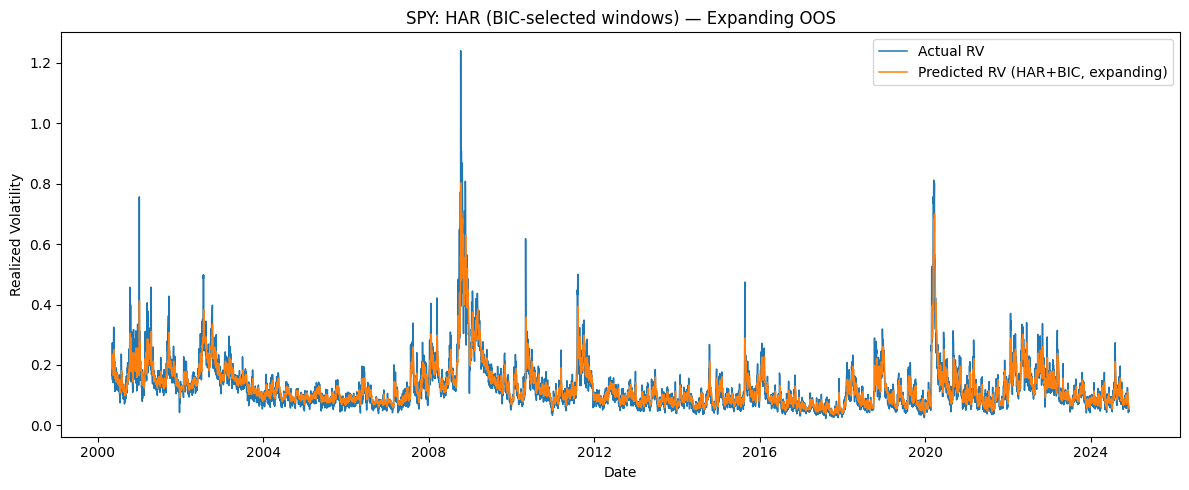

In [13]:
plt.figure(figsize=(12,5))
plt.plot(oos_har["date"], oos_har["RV_actual"],    label="Actual RV", linewidth=1.1)
plt.plot(oos_har["date"], oos_har["RV_predicted"], label="Predicted RV (HAR+BIC, expanding)", linewidth=1.1)
plt.title(f"{TICKER}: HAR (BIC-selected windows) — Expanding OOS")
plt.xlabel("Date"); plt.ylabel("Realized Volatility"); plt.legend(); plt.tight_layout(); plt.show()


In [14]:
# Align persistence forecast (y_{t-1}) on OOS dates
df_eval = oos_har.merge(rv.shift(1).rename("RV_lag1"), left_on="date", right_index=True, how="left")

y    = np.clip(df_eval["RV_actual"].to_numpy(float), _EPS, None)
yhat = np.clip(df_eval["RV_predicted"].to_numpy(float), _EPS, None)
yp   = np.clip(df_eval["RV_lag1"].to_numpy(float), _EPS, None)

mask = np.isfinite(y) & np.isfinite(yhat) & np.isfinite(yp)
y, yhat, yp = y[mask], yhat[mask], yp[mask]

# Metrics
mse   = float(np.mean((y - yhat)**2))
qlike = qlike_loss(y, yhat, assume_variance=ASSUME_SERIES_IS_VARIANCE)

# R^2 vs mean (plain) and OOS R^2 vs persistence (Campbell–Thompson)
ybar  = float(np.mean(y))
tss   = float(np.sum((y - ybar)**2))
sse   = float(np.sum((y - yhat)**2))
sse_p = float(np.sum((y - yp)**2))

r2_mean = 1 - sse/tss if tss > 0 else np.nan
r2_pers = 1 - sse/sse_p if sse_p > 0 else np.nan

print(f"OOS [{TICKER}]  MSE = {mse:.6g} | QLIKE = {qlike:.6g} | R^2(mean) = {r2_mean:.3f} | R^2(persist) = {r2_pers:.3f}")


OOS [SPY]  MSE = 0.00144454 | QLIKE = 0.119066 | R^2(mean) = 0.790 | R^2(persist) = 0.154
